In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/CodSoft_Task1/zomato_cleaned.csv')
print(df.shape)

(51588, 11)


In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

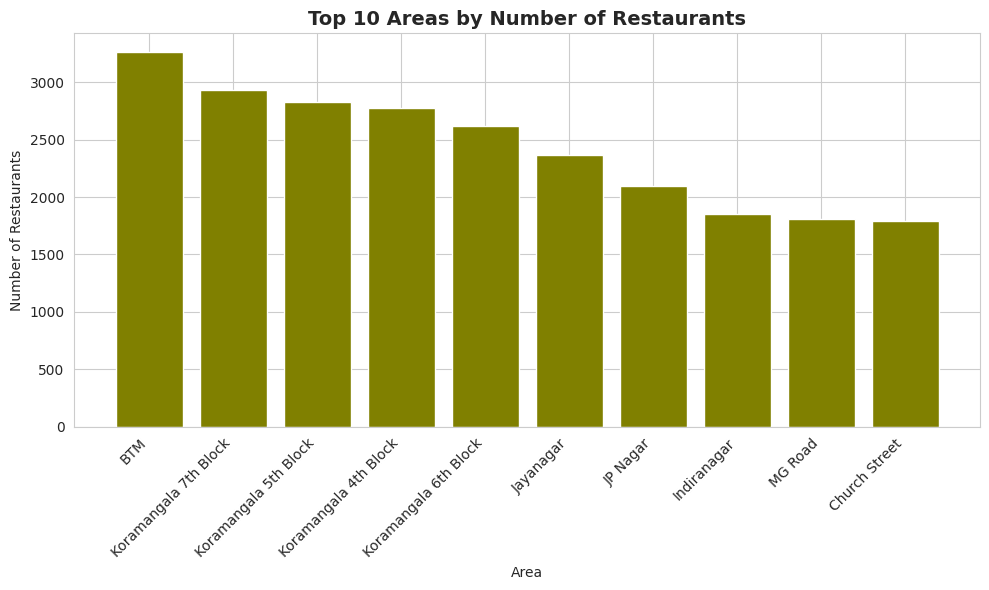

In [5]:
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_cities.index, top_cities.values, color='#808000')
plt.title('Top 10 Areas by Number of Restaurants', fontsize=14, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart1_top_cities.png', dpi=150)
plt.show()

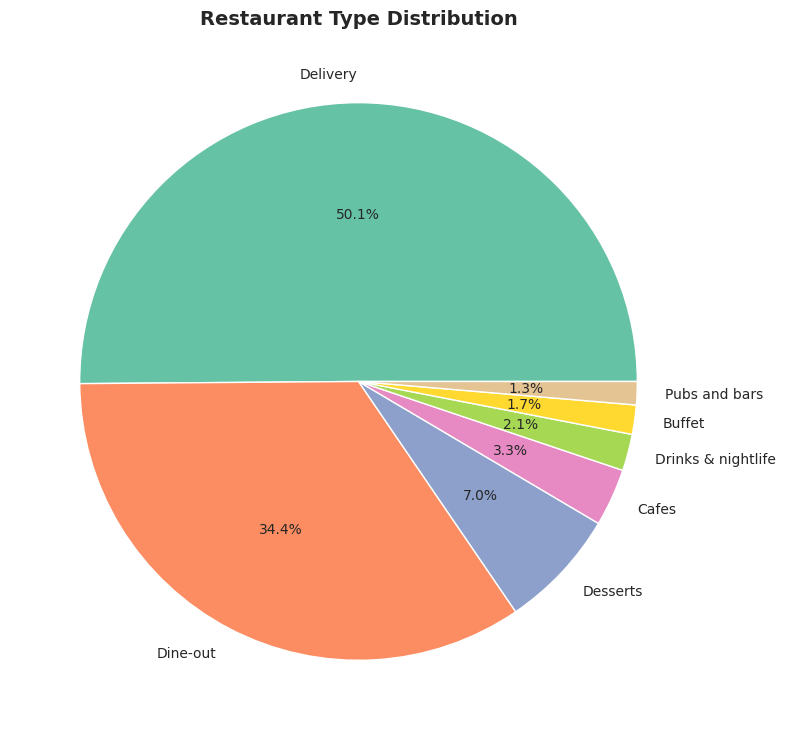

In [6]:
type_share = df['type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(type_share.values, labels=type_share.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
plt.title('Restaurant Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart2_type_pie.png', dpi=150)
plt.show()

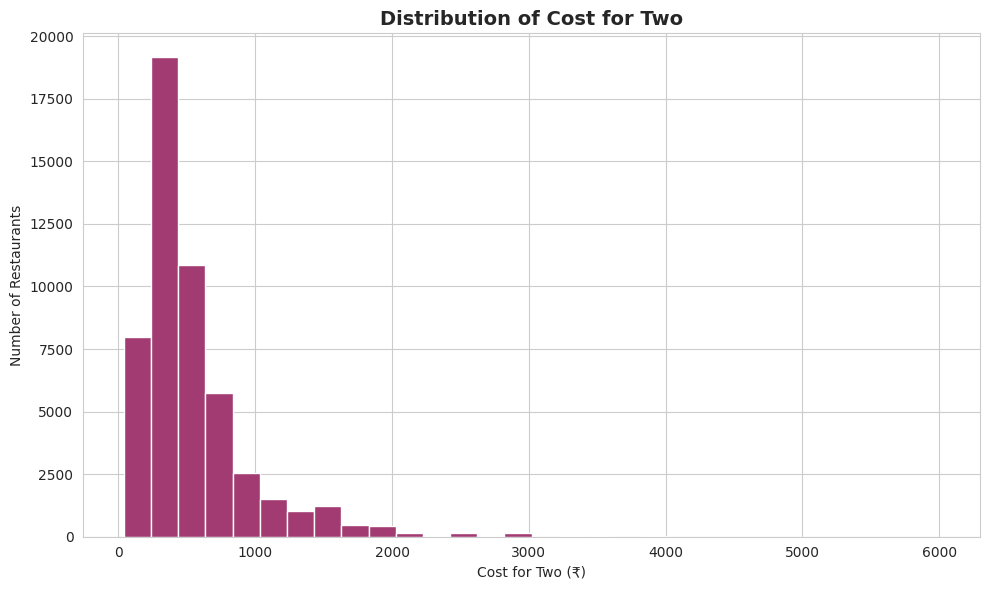

In [7]:
plt.figure(figsize=(10,6))
plt.hist(df['cost_for_two'], bins=30, color='#A23B72', edgecolor='white')
plt.title('Distribution of Cost for Two', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart3_cost_hist.png', dpi=150)
plt.show()

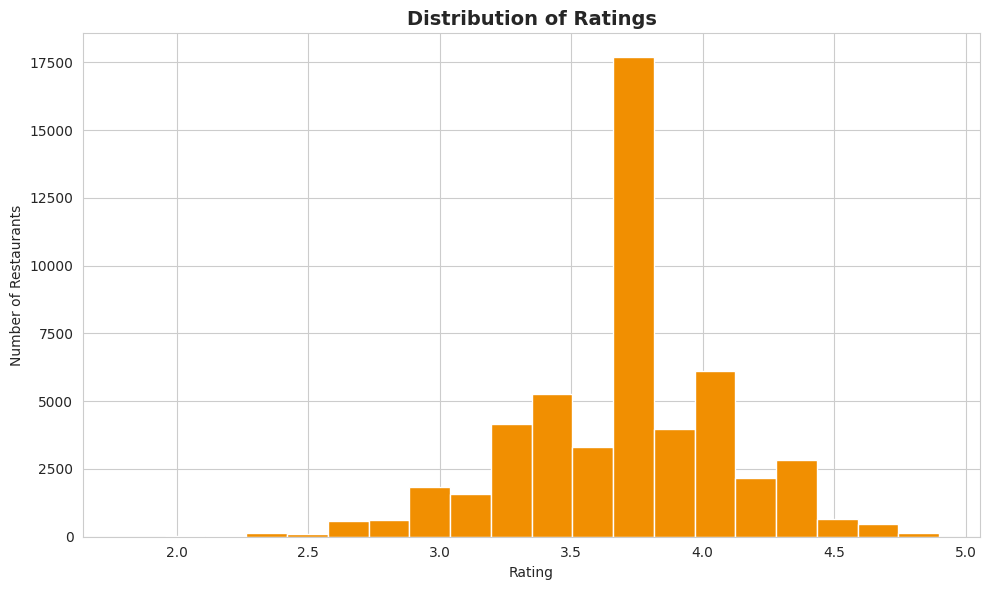

In [8]:
plt.figure(figsize=(10,6))
plt.hist(df['rate'], bins=20, color='#F18F01', edgecolor='white')
plt.title('Distribution of Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart4_rating_hist.png', dpi=150)
plt.show()

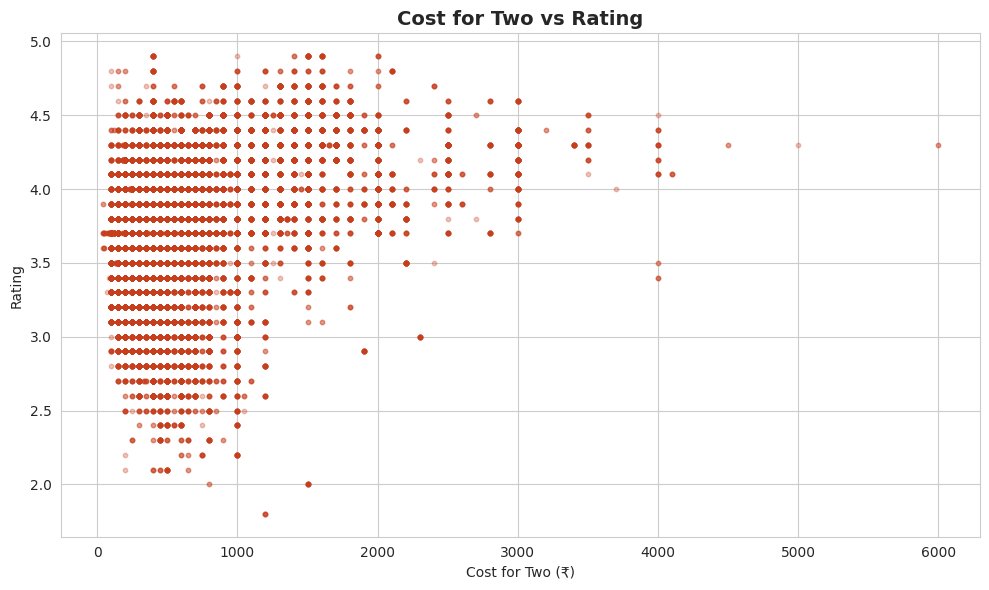

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(df['cost_for_two'], df['rate'], alpha=0.3, color='#C73E1D', s=10)
plt.title('Cost for Two vs Rating', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart5_cost_vs_rating.png', dpi=150)
plt.show()

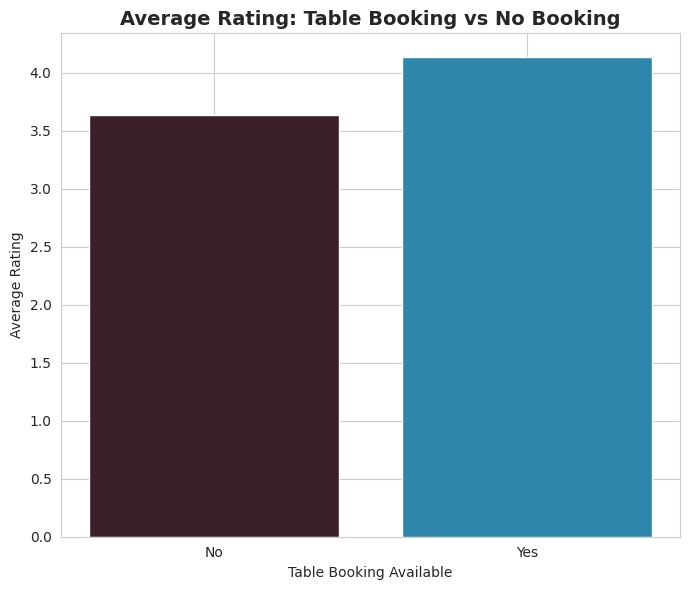

In [10]:
book_table_avg = df.groupby('book_table')['rate'].mean()

plt.figure(figsize=(7,6))
plt.bar(book_table_avg.index, book_table_avg.values, color=['#3B1F2B', '#2E86AB'])
plt.title('Average Rating: Table Booking vs No Booking', fontsize=14, fontweight='bold')
plt.xlabel('Table Booking Available')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart6_booktable_rating.png', dpi=150)
plt.show()

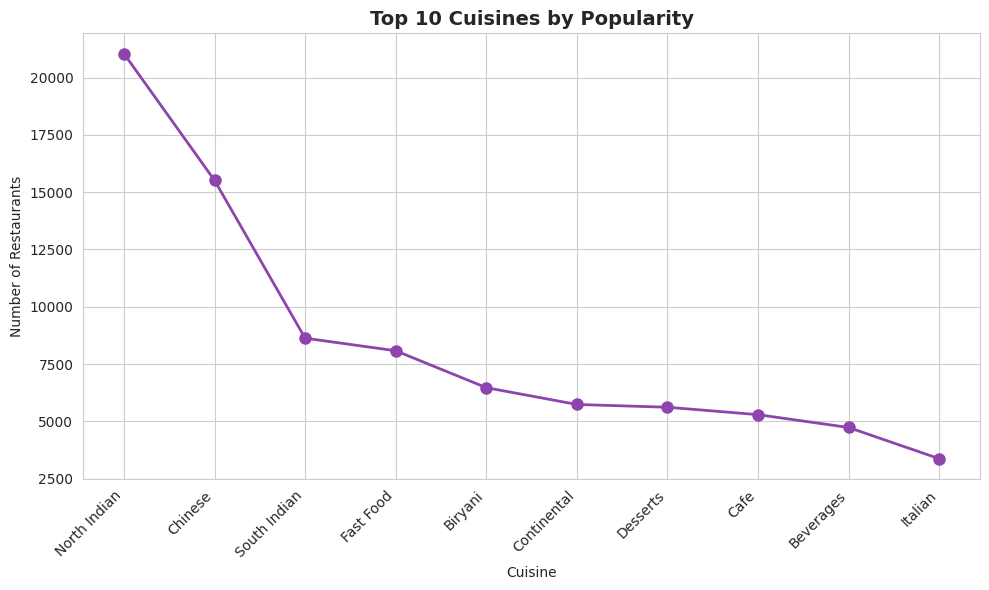

In [11]:
from collections import Counter

all_cuisines = df['cuisines'].str.split(', ').sum()
cuisine_counts = pd.Series(Counter(all_cuisines)).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.plot(cuisine_counts.index, cuisine_counts.values, marker='o',
         color='#8E44AD', linewidth=2, markersize=8)
plt.title('Top 10 Cuisines by Popularity', fontsize=14, fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/chart7_top_cuisines.png', dpi=150)
plt.show()

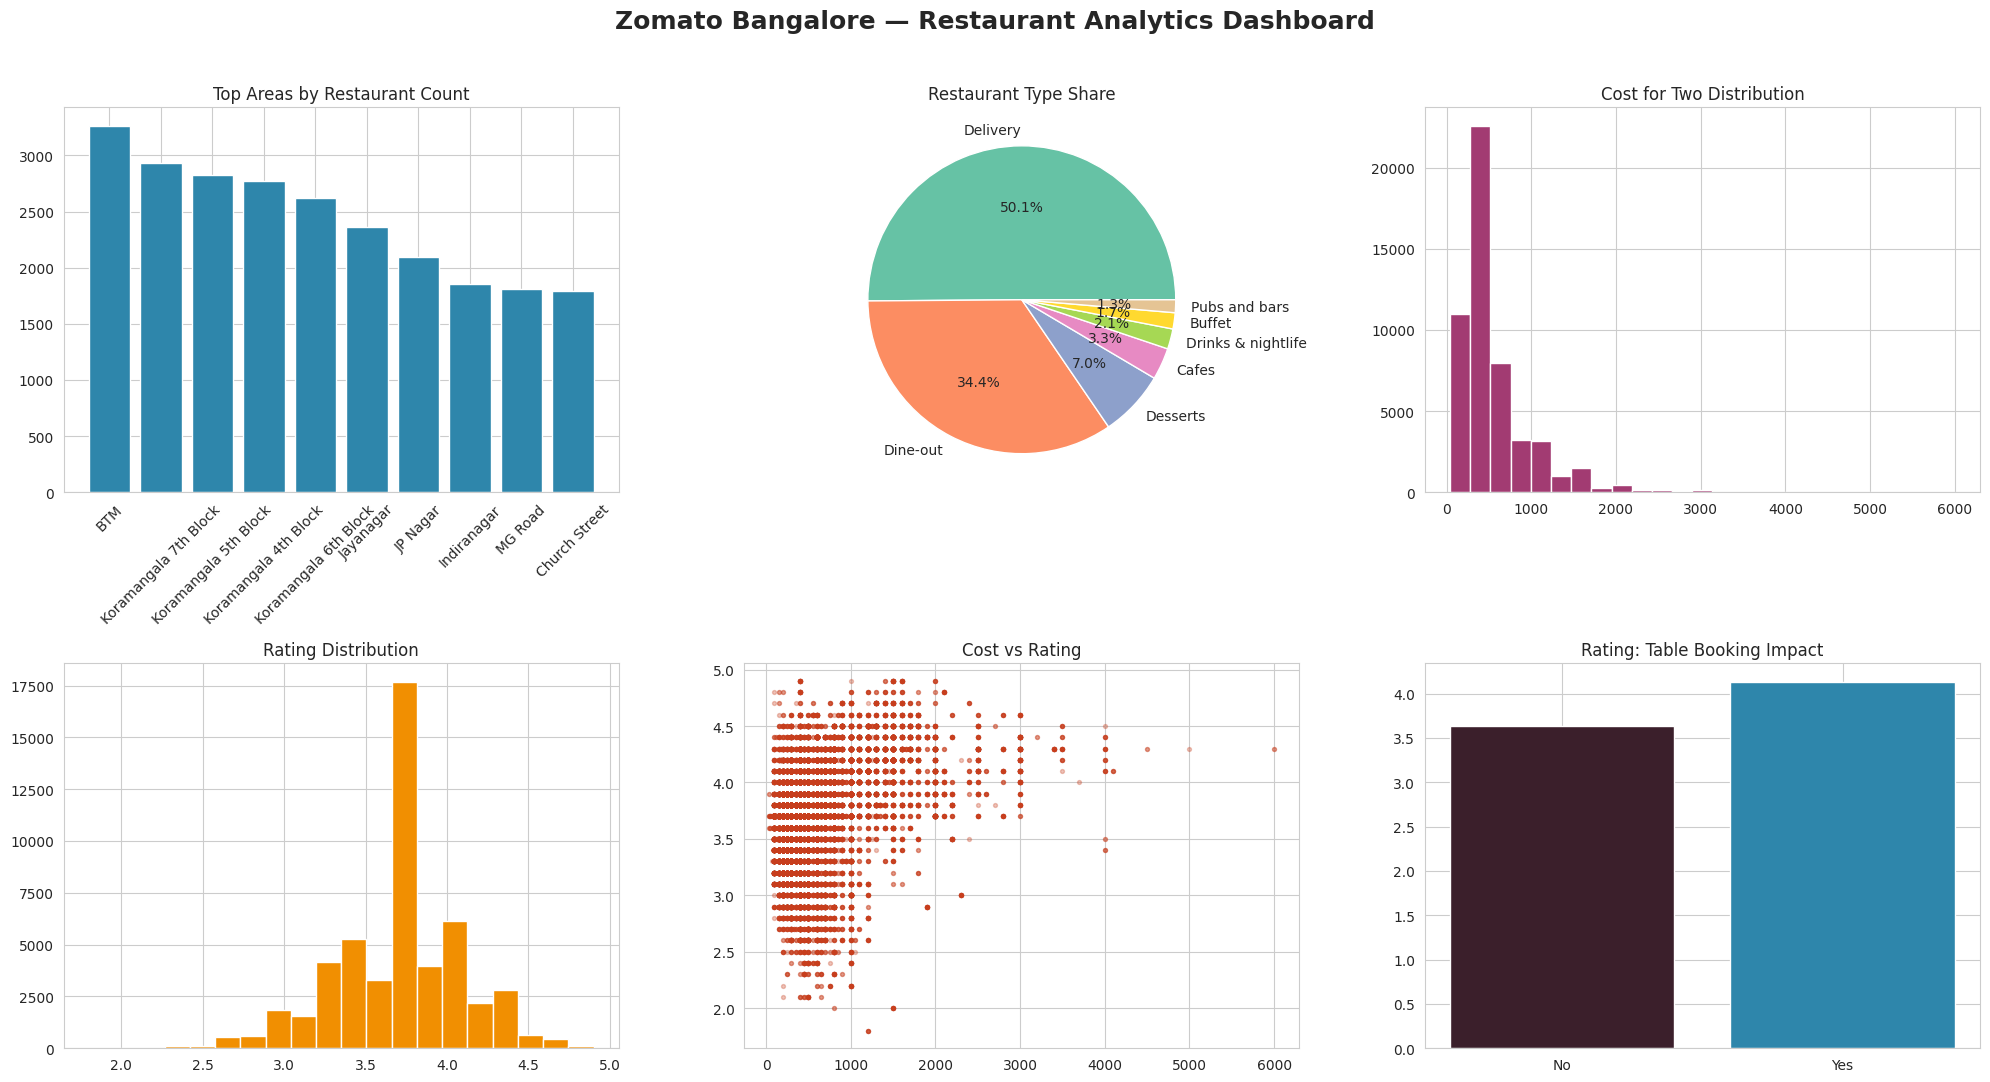

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Zomato Bangalore — Restaurant Analytics Dashboard', fontsize=18, fontweight='bold')

axes[0,0].bar(top_cities.index, top_cities.values, color='#2E86AB')
axes[0,0].set_title('Top Areas by Restaurant Count')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].pie(type_share.values, labels=type_share.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[0,1].set_title('Restaurant Type Share')

axes[0,2].hist(df['cost_for_two'], bins=25, color='#A23B72')
axes[0,2].set_title('Cost for Two Distribution')

axes[1,0].hist(df['rate'], bins=20, color='#F18F01')
axes[1,0].set_title('Rating Distribution')

axes[1,1].scatter(df['cost_for_two'], df['rate'], alpha=0.3, color='#C73E1D', s=8)
axes[1,1].set_title('Cost vs Rating')

axes[1,2].bar(book_table_avg.index, book_table_avg.values, color=['#3B1F2B','#2E86AB'])
axes[1,2].set_title('Rating: Table Booking Impact')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()